<a href="https://colab.research.google.com/github/nutof-pefoce/forensicRT/blob/main/notebooks/rt_ods_ecfp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_dir = '/content/drive/MyDrive/ML/'

Mounted at /content/drive


Data loading

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(data_dir + 'rt-ods_smiles.csv')
df.head(3)

,SMILES,RT
0,CCCCC/C=C\C/C=C\C/C=C\C/C=C\CCC(C)C(=O)NCCF,8.628
1,CC(O)CCCn1cc(C(=O)C2C(C)(C)C2(C)C)c2ccccc21,7.199
2,CC(C)[C@H](NC(=O)c1cn(CC2CCCCC2)c2ccccc12)C(N)=O,7.596


Fingerprint generation and data split

In [ ]:
!pip install scikit-fingerprints

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.4/522.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 24.4 MB/s eta 0:00:00


In [ ]:
from skfp.fingerprints import ECFPFingerprint
from sklearn.model_selection import train_test_split

smiles_column = df['SMILES']
target = df['RT'].values.reshape(-1, 1)

fp6 = ECFPFingerprint(fp_size=2048, radius=3, count=True)
fps = fp6.transform(smiles_column).astype('f')

train_opt_fps, val_test_fps, y_train_opt, y_val_test = train_test_split(fps, target.astype('f'), train_size=0.70, random_state=42)
train_fps, opt_fps, y_train, y_opt = train_test_split(train_opt_fps, y_train_opt, train_size=(0.55/0.70), shuffle=False)
val_fps, test_fps, y_val, y_test = train_test_split(val_test_fps, y_val_test, test_size=0.5, shuffle=False)

In [ ]:
print("Number of train samples: ", train_fps.shape[0])
print("Number of optim samples: ", opt_fps.shape[0])
print("Number of valid samples: ", val_fps.shape[0])
print("Number of test samples: ", test_fps.shape[0])
print("Number of tasks: ", y_train.shape[1])

Number of train samples:  310
Number of optim samples:  85
Number of valid samples:  85
Number of test samples:  85
Number of tasks:  1


Defining the neural network

In [ ]:
!pip install skorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.6/271.6 kB 4.1 MB/s eta 0:00:00


In [ ]:
from skorch import NeuralNetRegressor
from skorch.dataset import Dataset
from skorch.callbacks import EarlyStopping, LRScheduler
from skorch.helper import predefined_split
import torch
from torch import nn
import torch.nn.functional as F

In [ ]:
# Setting the random seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.use_deterministic_algorithms(mode=True, warn_only=True)

In [ ]:
class RegressorModule(nn.Module):
    def __init__(
            self,
            n_features=2048,
            num_units=128,
            activation='relu',
    ):
        if activation == 'relu':
            nonlin = F.relu
        elif activation == 'leaky_relu':
            nonlin = F.leaky_relu

        super(RegressorModule, self).__init__()
        self.num_units = num_units
        self.nonlin = nonlin

        self.dense = nn.Linear(n_features, num_units)
        self.output = nn.Linear(num_units, 1)

    def forward(self, X, **kwargs):
        X = self.nonlin(self.dense(X))
        X = self.output(X).type(torch.float32)

        return X

class RegularizedNet(NeuralNetRegressor):
    def __init__(self, *args, alpha=0.01, **kwargs):
        super().__init__(*args, **kwargs)
        self.alpha = alpha

    def get_loss(self, y_pred, y_true, X=None, training=False):
        loss = super().get_loss(y_pred, y_true, X=X, training=training)
        l2_penalty = sum((w ** 2).sum() for w in self.module_.parameters())
        loss += 0.5 * self.alpha * l2_penalty

        return loss

Setting and training the neural regressor

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
nnr = NeuralNetRegressor(
    RegressorModule, verbose=1,
    module__num_units=512,
    max_epochs=2000,
    optimizer=torch.optim.SGD,
    optimizer__lr=0.001,
    optimizer__momentum=0.90,
    optimizer__weight_decay=0.01,
    optimizer__nesterov=True,
    callbacks=[EarlyStopping(monitor='valid_loss', threshold=0.001)],
    train_split=predefined_split(Dataset(opt_fps, y_opt)),
    )

nnr.fit(train_fps, y_train)

train_pred = nnr.predict(train_fps)
opt_pred = nnr.predict(opt_fps)

train_r_squared = r2_score(y_train, train_pred)
train_mae = mean_absolute_error(y_train, train_pred)

opt_r_squared = r2_score(y_opt, opt_pred)
opt_mae = mean_absolute_error(y_opt, opt_pred)

print(f"train R²: {train_r_squared:.3f}")
print(f"train MAE: {train_mae:.3f}")
print(f"optimization R²: {opt_r_squared:.3f}")
print(f"optimization MAE: {opt_mae:.3f}")

  epoch    train_loss    valid_loss     dur
-------  ------------  ------------  ------
      1       27.9769       18.3404  0.2309
      2       11.6031        2.6548  0.0540
      3        3.7733        3.8740  0.0710
      4        3.6216        2.1063  0.0844
      5        1.5926        2.3841  0.0793
      6        1.5186        1.5832  0.0775
      7        1.1423        1.3113  0.0733
      8        1.0664        1.2465  0.0746
      9        0.9771        1.2260  0.0782
     10        0.9404        1.1563  0.0743
     11        0.8950        1.0977  0.0723
     12        0.8536        1.0669  0.0717
     13        0.8177        1.0453  0.0728
     14        0.7851        1.0221  0.0724
     15        0.7531        1.0001  0.0721
     16        0.7230        0.9825  0.0739
     17        0.6960        0.9677  0.0706
     18        0.6715        0.9535  0.0728
     19        0.6485        0.9395  0.0699
     20        0.6268        0.9257  0.0683
     21        0.6061        0.9

Hyperparameters tuning

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 24.5 MB/s eta 0:00:00


In [ ]:
import optuna

def objective(trial):

  num_units = trial.suggest_int('num_units', 6, 9)
  lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
  weight_decay = trial.suggest_float('weight_decay', 1e-4, 1e-2, log=True)


  nnr = NeuralNetRegressor(
    RegressorModule, verbose=0,
    module__num_units=(2 ** num_units),
    max_epochs=500,
    optimizer=torch.optim.SGD,
    optimizer__lr=lr,
    optimizer__momentum=0.9,
    optimizer__weight_decay=weight_decay,
    optimizer__nesterov=True,
    callbacks=[EarlyStopping(monitor='valid_loss', threshold=0.001)],
    train_split=predefined_split(Dataset(opt_fps, y_opt)),
    )

  nnr.fit(train_fps, y_train)

  val_pred = nnr.predict(val_fps)
  valid_loss = mean_absolute_error(y_val, val_pred)

  return valid_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print(study.best_trial)

[I 2026-03-04 16:15:44,218] A new study created in memory with name: no-name-2e7fdbb5-9d19-4416-bfce-52e61d8c1a22
[I 2026-03-04 16:15:53,406] Trial 0 finished with value: 0.498538613319397 and parameters: {'num_units': 9, 'lr': 0.0029001791698325965, 'weight_decay': 0.0035890673569470297}. Best is trial 0 with value: 0.498538613319397.
[I 2026-03-04 16:16:07,767] Trial 1 finished with value: 0.5203534364700317 and parameters: {'num_units': 8, 'lr': 0.0005147151990749817, 'weight_decay': 0.00013498188874917202}. Best is trial 0 with value: 0.498538613319397.
[I 2026-03-04 16:16:35,286] Trial 2 finished with value: 0.5504351258277893 and parameters: {'num_units': 9, 'lr': 0.00012099104523931468, 'weight_decay': 0.0071520794665004064}. Best is trial 0 with value: 0.498538613319397.
[I 2026-03-04 16:17:03,426] Trial 3 finished with value: 0.5297787189483643 and parameters: {'num_units': 9, 'lr': 0.0002944073110541012, 'weight_decay': 0.0003521900977938304}. Best is trial 0 with value: 0.49

FrozenTrial(number=14, state=<TrialState.COMPLETE: 1>, values=[0.49471813440322876], datetime_start=datetime.datetime(2026, 3, 4, 16, 18, 9, 624993), datetime_complete=datetime.datetime(2026, 3, 4, 16, 18, 19, 57654), params={'num_units': 9, 'lr': 0.0020816496621998554, 'weight_decay': 0.0009470281630337134}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'num_units': IntDistribution(high=9, log=False, low=6, step=1), 'lr': FloatDistribution(high=0.01, log=True, low=0.0001, step=None), 'weight_decay': FloatDistribution(high=0.01, log=True, low=0.0001, step=None)}, trial_id=14, value=None)


In [ ]:
import time

train_preds = []
val_preds = []
test_preds = []

num_runs = 5

start_time = time.perf_counter()

for _ in range(num_runs):

    nnr = NeuralNetRegressor(
      RegressorModule, verbose=0,
      module__num_units=512,
      max_epochs=500,
      optimizer=torch.optim.SGD,
      optimizer__lr=0.0021,
      optimizer__momentum=0.9,
      optimizer__weight_decay=0.00095,
      optimizer__nesterov=True,
      callbacks=[EarlyStopping(monitor='valid_loss', threshold=0.001)],
      train_split=predefined_split(Dataset(opt_fps, y_opt)),
      )

    nnr.fit(train_fps, y_train)

    train_pred = nnr.predict(train_fps)
    val_pred = nnr.predict(val_fps)
    test_pred = nnr.predict(test_fps)

    train_preds.append(train_pred)
    val_preds.append(val_pred)
    test_preds.append(test_pred)

end_time = time.perf_counter()

elapsed_time = end_time - start_time
average_time_per_run = elapsed_time / num_runs

train_pred = np.mean(train_preds, axis=0)
val_pred = np.mean(val_preds, axis=0)
test_pred = np.mean(test_preds, axis=0)

train_r_squared = r2_score(y_train, train_pred)
train_mae = mean_absolute_error(y_train, train_pred)

val_r_squared = r2_score(y_val, val_pred)
val_mae = mean_absolute_error(y_val, val_pred)

test_r_squared = r2_score(y_test, test_pred)
test_mae = mean_absolute_error(y_test, test_pred)

print(f"train R²: {train_r_squared:.3f}")
print(f"train MAE: {train_mae:.3f}")
print(f"validation R²: {val_r_squared:.3f}")
print(f"validation MAE: {val_mae:.3f}")
print(f"test R²: {test_r_squared:.3f}")
print(f"test MAE: {test_mae:.3f}")

print(f"Average time per run: {average_time_per_run:.2f} seconds")

train R²: 0.990
train MAE: 0.127
validation R²: 0.840
validation MAE: 0.516
test R²: 0.898
test MAE: 0.407
Average time per run: 9.51 seconds


Store test predictions

In [ ]:
train_opt_df, val_test_df = train_test_split(df, train_size=0.70, random_state=42)
train_df, opt_df = train_test_split(train_opt_df, train_size=(0.55/0.70), shuffle=False)
val_df, test_df = train_test_split(val_test_df, test_size=0.5, shuffle=False)

datasets = {
    "train": train_df.reset_index(),
    "optim": opt_df.reset_index(),
    "valid": val_df.reset_index(),
    "test": test_df.reset_index()
}

predictions = {
    "train": np.array(train_preds),
    "valid": np.array(val_preds),
    "test": np.array(test_preds)
}

for dataset_name in predictions.keys():
    dataset = datasets[dataset_name] # Get the corresponding dataset from the original 'datasets' dict
    pred_list = []
    for i in range(num_runs):
        pred_run = pd.DataFrame(predictions[dataset_name][i].squeeze(), columns=[f'pred RT run {i+1}'])
        pred_list.append(pred_run)

    pred_df = pd.concat(pred_list, axis=1)
    pred_df['avg pred RT'] = pred_df.mean(axis=1)
    substance = pd.DataFrame(dataset, columns=['SMILES'])
    substance = substance.rename(columns={'SMILES': 'Compound'})
    exp_rt = pd.DataFrame(dataset, columns=['RT'])
    exp_rt = exp_rt.rename(columns={'RT': 'exp RT'})
    predictions_df = pd.concat([substance, exp_rt, pred_df], axis=1)

    # Calculate the 'Error' column
    predictions_df['Error'] = predictions_df['avg pred RT'] - predictions_df['exp RT']

    # Define a function to classify errors into windows
    def classify_error(error):
        if error < -2:
            return '< -2 min'
        elif -2 <= error < -1:
            return '-2 to -1 min'
        elif -1 <= error < -0.5:
            return '-1 to -0.5 min'
        elif -0.5 <= error <= 0.5:
            return '± 0.5 min'
        elif 0.5 < error <= 1:
            return '0.5 to 1 min'
        elif 1 < error <= 2:
            return '1 to 2 min'
        else:
            return '> 2 min'

    # Apply the function to create the 'error window' column
    predictions_df['error window'] = predictions_df['Error'].apply(classify_error)

    display(predictions_df)  # Display the updated DataFrame
    print(f"Displaying the {dataset_name} dataset with predictions and error information.")

    #Save to CSV
    predictions_df.to_csv(data_dir + f"rt_ods_{dataset_name}_ecfp6_preds.csv", index=False)
    print(f'{dataset_name.capitalize()} predictions succesfully saved to csv.')

,Compound,exp RT,pred RT run 1,pred RT run 2,pred RT run 3,pred RT run 4,pred RT run 5,avg pred RT,Error,error window
0,O=C(Oc1cccc2cccnc12)c1cn(CCCCCF)c2ccccc12,7.085,7.068019,7.083933,7.062725,7.098575,7.086139,7.079878,-0.005122,± 0.5 min
1,CCc1cc(OC)c(CC(C)N)cc1OC,5.695,5.575032,5.559550,5.575022,5.600163,5.609504,5.583854,-0.111146,± 0.5 min
2,COc1ccc2[nH]cc(CCNC(C)=O)c2c1,4.790,4.381131,4.317819,4.329383,4.344696,4.342879,4.343181,-0.446819,± 0.5 min
3,CCCc1nc(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(CC...,6.104,6.129360,6.150628,6.146077,6.117105,6.147274,6.138089,0.034089,± 0.5 min
4,c1cc2c(cc1CN1CCNCC1)OCO2,2.701,2.772493,2.788036,2.781934,2.767884,2.760045,2.774078,0.073078,± 0.5 min
...,...,...,...,...,...,...,...,...,...,...
305,Cc1ccc(C(=O)c2cn(CCCC(C)F)c3ccccc23)c2ccccc12,7.611,7.598094,7.592193,7.602479,7.603713,7.586369,7.596570,-0.014430,± 0.5 min
306,CCN(CC)CCc1c[nH]c2ccccc12,3.893,3.730062,3.739432,3.716565,3.740560,3.737010,3.732726,-0.160274,± 0.5 min
307,COc1cc([N+](=O)[O-])c(OC)cc1CCN,3.768,3.783558,3.787241,3.775811,3.779212,3.778110,3.780786,0.012786,± 0.5 min
308,CCCCn1cc(C(=O)c2ccc(OC)cc2)c2ccccc21,7.328,7.449694,7.458408,7.446619,7.454803,7.441482,7.450202,0.122202,± 0.5 min


Displaying the train dataset with predictions and error information.
Train predictions succesfully saved to csv.


,Compound,exp RT,pred RT run 1,pred RT run 2,pred RT run 3,pred RT run 4,pred RT run 5,avg pred RT,Error,error window
0,COC1=CC=C2[C@H]3Cc4ccc(OC)c5c4[C@@]2(CCN3C)[C@...,4.158,4.121728,3.961975,3.841088,4.115266,4.100570,4.028126,-0.129874,± 0.5 min
1,c1ccc(C2(N3CCCC3)CCCCC2)cc1,5.054,4.841063,4.854591,4.813520,4.855718,4.819504,4.836879,-0.217121,± 0.5 min
2,COc1ccc(C(=O)c2c(C)n(CCN3CCOCC3)c3cc(I)ccc23)cc1,7.253,6.693429,6.285000,6.516332,6.396403,6.492535,6.476740,-0.776260,-1 to -0.5 min
3,COC(=O)C1CC(OC(C)=O)C(=O)C2C1(C)CCC1C(=O)OC(c3...,6.669,5.326052,5.295655,5.107852,5.187634,5.267931,5.237025,-1.431975,-2 to -1 min
4,CCCCCn1cc(C(=O)Oc2cccc3cccnc23)c2ccccc21,7.633,7.599915,7.638829,7.618616,7.653946,7.635033,7.629268,-0.003732,± 0.5 min
...,...,...,...,...,...,...,...,...,...,...
80,CCCCn1cc(C(=O)c2cccc3ccccc23)c2cccc(O)c21,7.331,7.538881,7.470849,7.533679,7.496623,7.475595,7.503125,0.172125,± 0.5 min
81,CCC(NC)C(=O)c1ccccc1,3.116,3.346278,3.352084,3.320637,3.316977,3.351593,3.337514,0.221514,± 0.5 min
82,CN1CCCCC(n2cc(C(=O)c3cccc4ccccc34)c3ccccc32)C1,5.795,6.932439,6.949333,6.980000,6.970891,6.885236,6.943580,1.148580,1 to 2 min
83,CCC(Cc1ccc(O)c(OC)c1)NC,3.290,3.184852,3.212709,3.259508,3.238735,3.230084,3.225177,-0.064823,± 0.5 min


Displaying the valid dataset with predictions and error information.
Valid predictions succesfully saved to csv.


,Compound,exp RT,pred RT run 1,pred RT run 2,pred RT run 3,pred RT run 4,pred RT run 5,avg pred RT,Error,error window
0,CNC(CC(C)C)C1(c2ccc(Cl)cc2)CCC1,6.524,6.692513,6.659445,6.660420,6.660757,6.650506,6.664728,0.140728,± 0.5 min
1,CCCCCn1cc(C(=O)Cc2ccc(OC)cc2)c2ccccc21,7.536,7.590127,7.622859,7.661292,7.612352,7.642419,7.625810,0.089810,± 0.5 min
2,CCCc1nc(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCNCC4...,6.047,6.295969,6.222292,6.172849,6.167246,6.241560,6.219983,0.172983,± 0.5 min
3,COc1cc(OC)c(CC(C)N)c(OC)c1,4.881,4.306407,4.435025,4.383164,4.344027,4.232873,4.340299,-0.540701,-1 to -0.5 min
4,CCCCCCC(C(=O)c1ccc(OC)cc1)N1CCCC1,5.933,6.034961,6.056056,6.038688,6.070253,6.032829,6.046557,0.113557,± 0.5 min
...,...,...,...,...,...,...,...,...,...,...
80,CCC(C(=O)c1ccc2c(c1)OCO2)N1CCCC1,3.537,3.673769,3.632986,3.678659,3.687611,3.702046,3.675014,0.138014,± 0.5 min
81,CCCCCn1cc(C(=O)c2ccc(C)c3ccccc23)c2ccccc21,8.933,8.499347,8.564728,8.410147,8.441369,8.472672,8.477653,-0.455347,± 0.5 min
82,COc1ccccc1CC(=O)c1cn(CCC2CCCCC2)c2ccccc12,8.213,8.347767,8.087445,8.049126,8.017418,8.023423,8.105036,-0.107964,± 0.5 min
83,CNC1(c2ccccc2Cl)CCCCC1=O,4.183,4.486485,4.566344,4.512818,4.550739,4.564126,4.536103,0.353103,± 0.5 min


Displaying the test dataset with predictions and error information.
Test predictions succesfully saved to csv.


Model interpretability and substructure importance

In [ ]:
import shap

train_fps_summary = shap.kmeans(train_fps, 5)

explainer = shap.KernelExplainer(nnr.predict, train_fps_summary)
shap_values = explainer.shap_values(val_fps[:15])
shap_values_mean = shap_values.mean(axis=0).reshape(-1)

  0%|          | 0/15 [00:00<?, ?it/s]

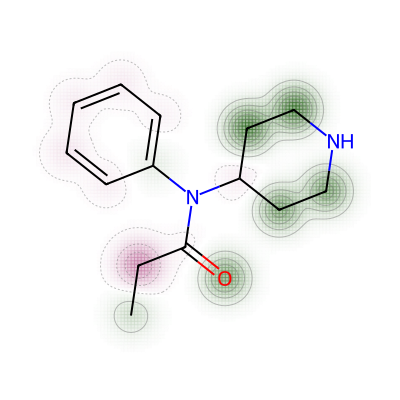

In [ ]:
from rdkit.Chem import AllChem, Draw, MolFromSmiles, rdFingerprintGenerator
from rdkit.Chem.Draw import SimilarityMaps
from IPython.display import Image, display, SVG

mol_smiles = 'CCC(=O)N(C1CCNCC1)C2=CC=CC=C2'

def draw_mol_with_importances(mol_smiles, importances):
    this_mol = MolFromSmiles(mol_smiles)
    morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=3, fpSize=2048, includeChirality=False)
    ao = rdFingerprintGenerator.AdditionalOutput()
    ao.AllocateAtomToBits()
    this_fp = list(morgan_gen.GetFingerprint(this_mol, additionalOutput=ao))
    atom_to_bits = ao.GetAtomToBits()
    atom_importances = [
    np.mean([importances[bit] for bit in bits]) if bits else 0.0
    for bits in atom_to_bits ]

    drawObj = Draw.rdMolDraw2D.MolDraw2DCairo(400, 400)
    smap = SimilarityMaps.GetSimilarityMapFromWeights(this_mol, atom_importances, drawObj, contourLines=10) #'PiYG'
    drawObj.FinishDrawing()
    png_file = 'similarity_map.png'
    smap.WriteDrawingText(png_file)
    return display(Image(filename=png_file))

draw_mol_with_importances(mol_smiles, shap_values_mean)

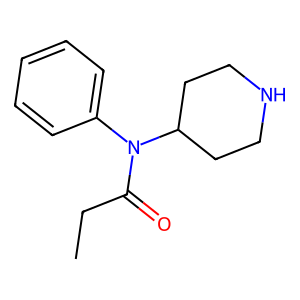

In [ ]:
this_mol = MolFromSmiles(mol_smiles)
Draw.MolToImage(this_mol)

Sample feature prediction

In [ ]:
sample_mol_smiles = 'O=CCCCCCC(C(=O)c1ccccc1)N1CCCC1'

sample_mol_fps = fp6.transform([sample_mol_smiles]).astype('f')

sample_rt = nnr.predict(sample_mol_fps).item()

print(f"Predicted RT: {sample_rt:.3f} min")

Predicted RT: 4.773 min


In [ ]:
mol_smiles = 'O=CCCCCCC(C(=O)c1ccccc1)N1CCCC1'

def ecfp_from_mol_smiles(mol_smiles, radius=3, fpSize=2048):
    morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=fpSize, includeChirality=False)
    this_mol = Chem.MolFromSmiles(mol_smiles)
    this_count_fp = np.array(list(morgan_gen.GetCountFingerprint(this_mol)), dtype='float32').reshape(1, -1)
    mol_fps = np.concatenate([this_count_fp, np.zeros(fpSize).astype('float32').reshape(1, -1)])
    return mol_fps

mol_fps = ecfp_from_mol_smiles(mol_smiles)

rt = nnr.predict(mol_fps)
print(f"Predicted RT: {rt[0]:.3f} min")

Predicted RT: 4.766 min


In [ ]:
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(nnr, val_fps, y_val, scoring='neg_mean_absolute_error', n_repeats=3)
perm_imp_mean = perm_imp.importances_mean

In [ ]:
import random
import pandas as pd
import numpy as np
import pickle
from rdkit import Chem


from sklearn.inspection import permutation_importance
from sklearn.preprocessing import MinMaxScaler


import optuna
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
train_df = pd.read_csv(data_dir + "rt_ods_train_preds.csv")
val_df = pd.read_csv(data_dir + "rt_ods_valid_preds.csv")
test_df = pd.read_csv(data_dir + "rt_ods_test_preds.csv")
opt_df = pd.read_csv(data_dir + "rt_ods_optim_preds.csv")

In [ ]:
def ecfp_from_smiles_column(smiles_column, radius=3, fpSize=2048):

    morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=fpSize, includeChirality=False)
    mols = smiles_column.apply(Chem.MolFromSmiles)
    fps = [morgan_gen.GetCountFingerprint(mol) for mol in mols]
    fps_lists = [list(l) for l in fps]
    fps_array = np.array(fps_lists, dtype='float32')

    return fps_array

In [ ]:
radius = 3
fpSize = 2048

train_fps = ecfp_from_smiles_column(train_df['Compound'])
opt_fps = ecfp_from_smiles_column(opt_df['Compound'])
val_fps = ecfp_from_smiles_column(val_df['Compound'])
test_fps = ecfp_from_smiles_column(test_df['Compound'])

In [ ]:
y_train = train_df['exp RT'].astype('float32')
y_opt = opt_df['exp RT'].astype('float32')
y_val = val_df['exp RT'].astype('float32')
y_test = test_df['exp RT'].astype('float32')

In [ ]:
def objective(trial):

  num_units = trial.suggest_int('num_units', 4, 10)
  #activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
  alpha = trial.suggest_float('alpha', 1e-7, 1e-3, log=True)
  tol = trial.suggest_float('tol', 1e-3, 1e-1, log=True)

  nnr = RegularizedNet(
    RegressorModule, verbose=0,
    module__n_features=fpSize,
    module__num_units=(2 ** num_units),
    alpha=alpha,
    max_epochs=200,
    optimizer=torch.optim.LBFGS,
    optimizer__line_search_fn='strong_wolfe',
    callbacks=[EarlyStopping(monitor='valid_loss', threshold=tol)],
    train_split=predefined_split(Dataset(opt_fps, y_opt)),
    )

  nnr.fit(train_fps, y_train)

  val_pred = nnr.predict(val_fps)
  valid_loss = mean_absolute_error(y_val, val_pred)

  return valid_loss

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print(study.best_trial)

[I 2026-02-11 13:50:50,642] A new study created in memory with name: no-name-baa5d702-4775-4f9a-b9a4-61755f26890d
[I 2026-02-11 13:51:01,363] Trial 0 finished with value: 0.5893471837043762 and parameters: {'num_units': 5, 'alpha': 2.5849610114815157e-06, 'tol': 0.03869152407201649}. Best is trial 0 with value: 0.5893471837043762.
[I 2026-02-11 13:51:09,087] Trial 1 finished with value: 0.5391119718551636 and parameters: {'num_units': 6, 'alpha': 3.148535743344883e-05, 'tol': 0.005401549004131241}. Best is trial 1 with value: 0.5391119718551636.
[I 2026-02-11 13:51:14,426] Trial 2 finished with value: 0.5457881093025208 and parameters: {'num_units': 4, 'alpha': 5.073767935923155e-07, 'tol': 0.008107424899368951}. Best is trial 1 with value: 0.5391119718551636.
[I 2026-02-11 13:53:34,383] Trial 3 finished with value: 0.44587525725364685 and parameters: {'num_units': 10, 'alpha': 9.106323460552114e-06, 'tol': 0.06440637734969946}. Best is trial 3 with value: 0.44587525725364685.
[I 2026-

FrozenTrial(number=11, state=<TrialState.COMPLETE: 1>, values=[0.4180036783218384], datetime_start=datetime.datetime(2026, 2, 11, 14, 1, 40, 682827), datetime_complete=datetime.datetime(2026, 2, 11, 14, 2, 27, 771684), params={'num_units': 8, 'alpha': 1.6013243002846206e-05, 'tol': 0.003783781078040159}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'num_units': IntDistribution(high=10, log=False, low=4, step=1), 'alpha': FloatDistribution(high=0.001, log=True, low=1e-07, step=None), 'tol': FloatDistribution(high=0.1, log=True, low=0.001, step=None)}, trial_id=11, value=None)


In [ ]:
!pip install shap

In [ ]:
nnr.module_

RegressorModule(
  (dense0): Linear(in_features=2048, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=1, bias=True)
)

In [ ]:
train_tensor = torch.tensor(train_fps)
train_tensor

val_tensor = torch.tensor(val_fps)
val_tensor

tensor([[0., 1., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 2., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [ ]:
perm_imp = permutation_importance(nnr, val_fps, y_val, scoring='neg_mean_absolute_error', n_repeats=3)
perm_imp_mean = perm_imp.importances_mean
perm_imp_scaled = -0.1 + ((perm_imp_mean - perm_imp_mean.min()) * 1.1) / (perm_imp_mean.max() - perm_imp_mean.min())